In [4]:
from pathlib import Path
import sys
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import DataLoader

from src.utils import load_config, apply_overrides, set_seed
from src.dataset_multitask import prepare_metadata, build_transforms
from src.splits import make_individual_level_splits

PROJECT_ROOT = Path.cwd()


In [5]:
cfg = load_config(PROJECT_ROOT / "config.yaml")

# # For dataset inspection, do not remove rare classes yet
# cfg = apply_overrides(cfg, [
#     "data.min_individuals_per_class=1"
# ])

set_seed(cfg["seed"])

print("Metadata CSV:", cfg["data"]["metadata_csv"])
print("Root dir:", cfg["data"]["root_dir"])
print("Image column:", cfg["data"]["image_col"])
print("Mask column:", cfg["data"].get("mask_col"))
print("Target column:", cfg["data"]["target_col"])
print("Group column:", cfg["data"]["group_col"])

Metadata CSV: ../petridish-worm-images/01_Segmented/global_metadata.csv
Root dir: ../petridish-worm-images
Image column: rel_path_seg
Mask column: rel_path_segmask
Target column: genus
Group column: barcode


In [6]:
cfg['data']['metadata_csv'] = '/mnt/extssd/Earthworms/petridish-worm-images/01_Segmented/global_metadata.csv'
cfg['data']['root_dir'] = '/mnt/extssd/Earthworms/petridish-worm-images'
df = prepare_metadata(cfg)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()


Strict species labels masked because of taxonomic uncertainty:
taxon_label
Aporrectodea_caliginosa_tuberculata    2115
Lumbricus_sp                            925
Name: count, dtype: int64
Initial dataset size: 6193
After removing invalid images, dataset size: 6191

Masking rare classes per task (min_individuals_per_class=3)

Classes retained for task 'genus' (genus):
genus
Aporrectodea     740
Lumbricus        189
Allolobophora    176
Name: barcode, dtype: int64

Classes retained for task 'species' (species_label):
species_label
Allolobophora_chlorotica          176
Aporrectodea_longa                159
Aporrectodea_tuberculata          105
Aporrectodea_rosea                 52
Aporrectodea_caliginosa            36
Lumbricus_festivus                 12
Lumbricus_terrestris_herculeus      8
Lumbricus_castaneus                 4
Name: barcode, dtype: int64

Classes retained for task 'age' (life_stage):
life_stage
Juvenile    823
Adult       282
Name: barcode, dtype: int64

Final usable

,timestamp,barcode,weight_g,index,filename,rel_path_raw,rel_path_seg,rel_path_segmask,species_dir,individual_dir,taxon_label,species_label,life_stage,genus,__taxon_for_split__
0,2025-09-05T09:42:24,Aporrectodea_rosea_Adult_14,0.312,1,Aporrectodea_rosea_Adult_14_1.jpg,01_Segmented/Aporrectodea_rosea_Adult_14/Aporr...,01_Segmented/Aporrectodea_rosea_Adult_14/Aporr...,01_Segmented/Aporrectodea_rosea_Adult_14/Aporr...,Aporrectodea_rosea_Adult_14,Aporrectodea_rosea_Adult_14_1,Aporrectodea_rosea,Aporrectodea_rosea,Adult,Aporrectodea,Aporrectodea_rosea
1,2025-09-05T09:42:24,Aporrectodea_rosea_Adult_14,0.312,2,Aporrectodea_rosea_Adult_14_2.jpg,01_Segmented/Aporrectodea_rosea_Adult_14/Aporr...,01_Segmented/Aporrectodea_rosea_Adult_14/Aporr...,01_Segmented/Aporrectodea_rosea_Adult_14/Aporr...,Aporrectodea_rosea_Adult_14,Aporrectodea_rosea_Adult_14_2,Aporrectodea_rosea,Aporrectodea_rosea,Adult,Aporrectodea,Aporrectodea_rosea
2,2025-09-05T09:42:24,Aporrectodea_rosea_Adult_14,0.312,5,Aporrectodea_rosea_Adult_14_5.jpg,01_Segmented/Aporrectodea_rosea_Adult_14/Aporr...,01_Segmented/Aporrectodea_rosea_Adult_14/Aporr...,01_Segmented/Aporrectodea_rosea_Adult_14/Aporr...,Aporrectodea_rosea_Adult_14,Aporrectodea_rosea_Adult_14_5,Aporrectodea_rosea,Aporrectodea_rosea,Adult,Aporrectodea,Aporrectodea_rosea
3,2025-09-05T09:42:24,Aporrectodea_rosea_Adult_14,0.312,4,Aporrectodea_rosea_Adult_14_4.jpg,01_Segmented/Aporrectodea_rosea_Adult_14/Aporr...,01_Segmented/Aporrectodea_rosea_Adult_14/Aporr...,01_Segmented/Aporrectodea_rosea_Adult_14/Aporr...,Aporrectodea_rosea_Adult_14,Aporrectodea_rosea_Adult_14_4,Aporrectodea_rosea,Aporrectodea_rosea,Adult,Aporrectodea,Aporrectodea_rosea
4,2025-09-05T09:42:24,Aporrectodea_rosea_Adult_14,0.312,3,Aporrectodea_rosea_Adult_14_3.jpg,01_Segmented/Aporrectodea_rosea_Adult_14/Aporr...,01_Segmented/Aporrectodea_rosea_Adult_14/Aporr...,01_Segmented/Aporrectodea_rosea_Adult_14/Aporr...,Aporrectodea_rosea_Adult_14,Aporrectodea_rosea_Adult_14_3,Aporrectodea_rosea,Aporrectodea_rosea,Adult,Aporrectodea,Aporrectodea_rosea


In [9]:

train_df, val_df, test_df = make_individual_level_splits(
    df=df,
    target_col=cfg["data"]["target_col"],
    group_col=cfg["data"]["group_col"],
    test_size=cfg["split"]["test_size"],
    val_size=cfg["split"]["val_size"],
    seed=cfg["seed"],
    root_dir='/home/devd/worm-species/'
)

Saved train/val/test splits to /home/devd/worm-species/


In [33]:
root_dir = Path(cfg["data"]["root_dir"])
image_col = cfg["data"]["image_col"]
mask_col = cfg["data"].get("mask_col")

def exists_in_root(rel_path):
    if pd.isna(rel_path):
        return False
    return (root_dir / rel_path).exists()

df[f"{image_col}_exists"] = df[image_col].apply(exists_in_root)

print(df[f"{image_col}_exists"].value_counts())
df_valid = df[df[f"{image_col}_exists"]].reset_index(drop=True)

print("Valid rows:", len(df_valid))
print("Removed rows:", len(df) - len(df_valid))

rel_path_seg_exists
True     6207
False       2
Name: count, dtype: int64
Valid rows: 6207
Removed rows: 2


In [34]:
group_col = cfg["data"]["group_col"]
target_col = cfg["data"]["target_col"]

summary = {
    "images": len(df_valid),
    "unique_individuals": df_valid[group_col].nunique(),
    "species": df_valid["species_label"].nunique(),
    "genera": df_valid["genus"].nunique(),
    "life_stages": df_valid["life_stage"].nunique(),
}

summary

{'images': 6207,
 'unique_individuals': 1107,
 'species': 12,
 'genera': 5,
 'life_stages': 2}

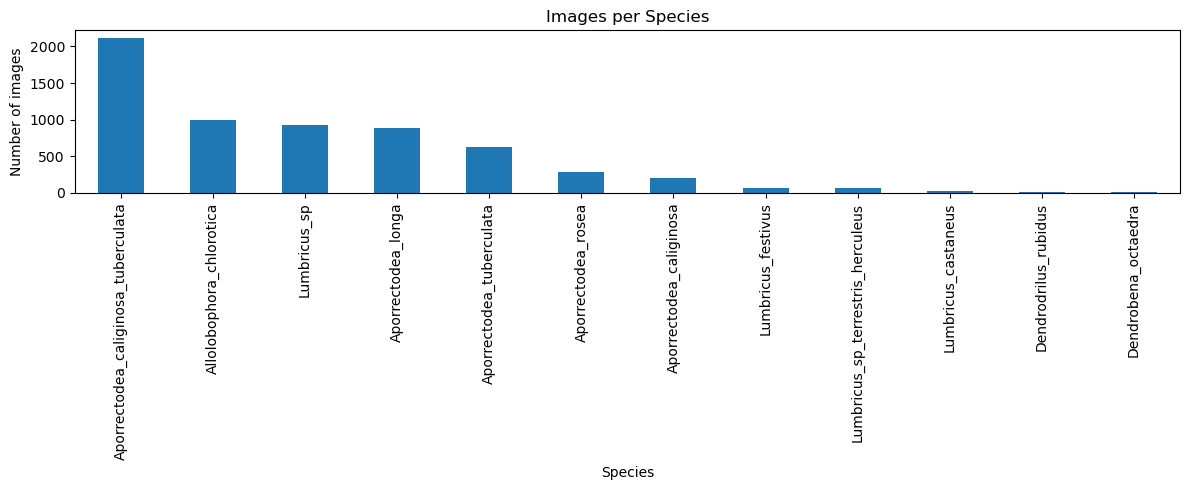

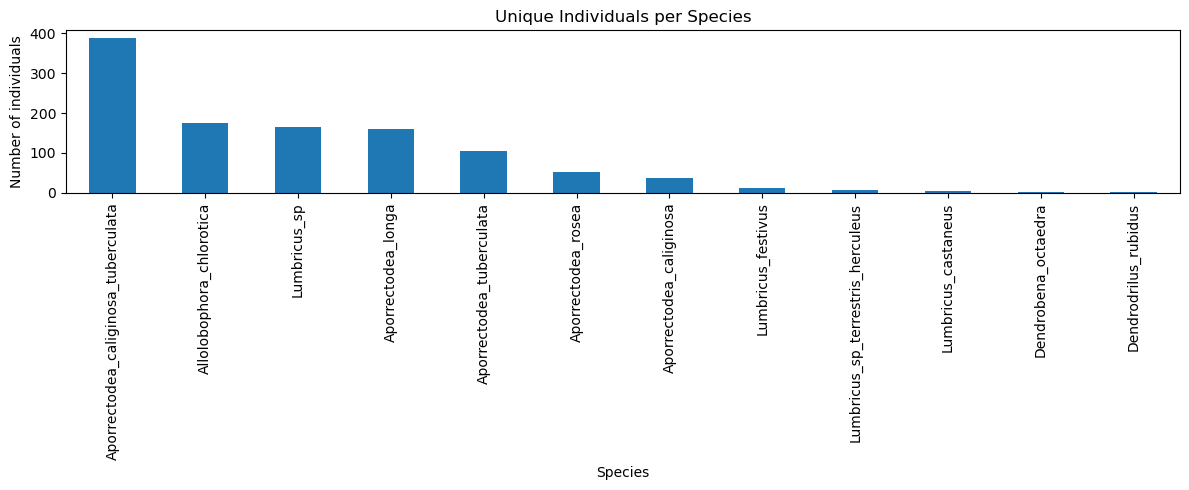

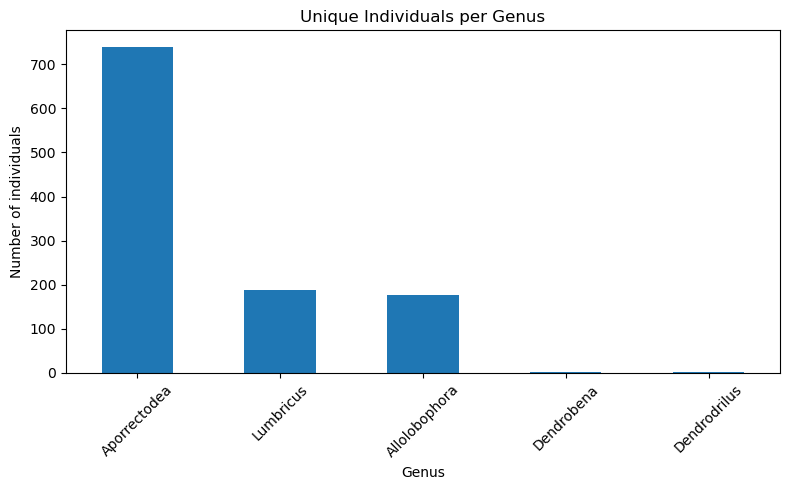

In [35]:
counts = df_valid["species_label"].value_counts()

plt.figure(figsize=(12, 5))
counts.plot(kind="bar")
plt.title("Images per Species")
plt.xlabel("Species")
plt.ylabel("Number of images")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

individual_counts = (
    df_valid
    .groupby("species_label")[group_col]
    .nunique()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 5))
individual_counts.plot(kind="bar")
plt.title("Unique Individuals per Species")
plt.xlabel("Species")
plt.ylabel("Number of individuals")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

genus_counts = (
    df_valid
    .groupby("genus")[group_col]
    .nunique()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
genus_counts.plot(kind="bar")
plt.title("Unique Individuals per Genus")
plt.xlabel("Genus")
plt.ylabel("Number of individuals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
cfg_model = load_config(PROJECT_ROOT / "config.yaml")

df_model = prepare_metadata(cfg_model)

train_df, val_df, test_df = make_individual_level_splits(
    df=df_model,
    target_col=cfg_model["data"]["target_col"],
    group_col=cfg_model["data"]["group_col"],
    test_size=cfg_model["split"]["test_size"],
    val_size=cfg_model["split"]["val_size"],
    seed=cfg_model["seed"],
    out_dir=cfg_model["split"]["output_dir"]
)

print("Train rows:", len(train_df))
print("Val rows:", len(val_df))
print("Test rows:", len(test_df))

print("Train individuals:", train_df[cfg_model["data"]["group_col"]].nunique())
print("Val individuals:", val_df[cfg_model["data"]["group_col"]].nunique())
print("Test individuals:", test_df[cfg_model["data"]["group_col"]].nunique())


labels = sorted(train_df[cfg_model["data"]["target_col"]].unique())
label_to_index = {label: i for i, label in enumerate(labels)}
index_to_label = {i: label for label, i in label_to_index.items()}

train_tf = build_transforms(
    image_size=cfg_model["data"]["image_size"],
    train=True
)

eval_tf = build_transforms(
    image_size=cfg_model["data"]["image_size"],
    train=False
)

train_ds = WormImageDataset(
    df=train_df,
    root_dir=cfg_model["data"]["root_dir"],
    image_col=cfg_model["data"]["image_col"],
    target_col=cfg_model["data"]["target_col"],
    label_to_index=label_to_index,
    transform=train_tf,
    mask_col=cfg_model["data"].get("mask_col"),
    crop_to_foreground=cfg_model["data"].get("crop_to_foreground", True),
    crop_pad=cfg_model["data"].get("crop_pad", 0.15),
)

val_ds = WormImageDataset(
    df=val_df,
    root_dir=cfg_model["data"]["root_dir"],
    image_col=cfg_model["data"]["image_col"],
    target_col=cfg_model["data"]["target_col"],
    label_to_index=label_to_index,
    transform=eval_tf,
    mask_col=cfg_model["data"].get("mask_col"),
    crop_to_foreground=cfg_model["data"].get("crop_to_foreground", True),
    crop_pad=cfg_model["data"].get("crop_pad", 0.15),
)

print("Train dataset:", len(train_ds))
print("Val dataset:", len(val_ds))
print("Number of classes:", len(label_to_index))


Classes retained:
species_label
Aporrectodea_caliginosa_tuberculata    388
Allolobophora_chlorotica               176
Lumbricus_sp                           165
Aporrectodea_longa                     159
Aporrectodea_tuberculata               105
Aporrectodea_rosea                      53
Aporrectodea_caliginosa                 36
Name: barcode, dtype: int64
Train rows: 3896
Val rows: 916
Test rows: 1227
Train individuals: 702
Val individuals: 163
Test individuals: 217
Train dataset: 3896
Val dataset: 916
Number of classes: 7


In [37]:
def unnormalize_image_tensor(x):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    x = x.cpu() * std + mean
    x = x.clamp(0, 1)

    return x.permute(1, 2, 0).numpy()

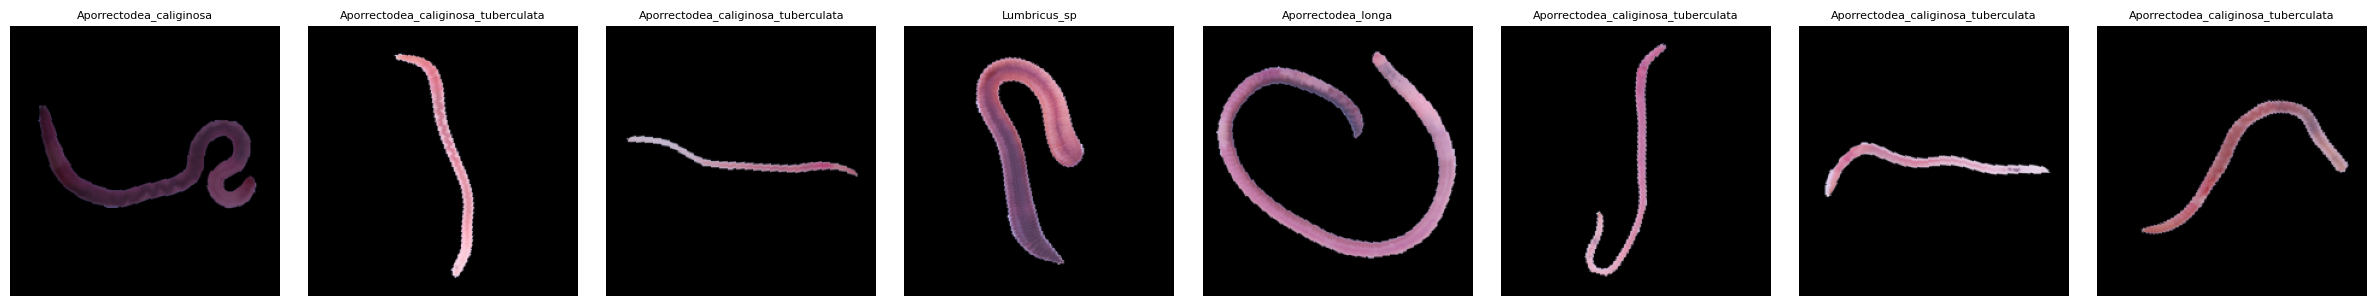

In [38]:
def show_dataset_samples(dataset, n=8, seed=42):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(dataset), size=min(n, len(dataset)), replace=False)

    fig, axes = plt.subplots(1, len(indices), figsize=(3 * len(indices), 3))

    if len(indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        item = dataset[int(idx)]
        img = unnormalize_image_tensor(item["image"])

        ax.imshow(img)
        ax.set_title(item["label_name"], fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    
    
show_dataset_samples(train_ds, n=8)

In [1]:
from src.utils import load_config
from src.dataset import prepare_metadata
from src.cache import build_image_cache

cfg = load_config("config.yaml")

df = prepare_metadata(cfg)
df_cached = build_image_cache(cfg, df)

df_cached[[
    cfg["data"]["image_col"],
    "_cached_image_path",
    "_cache_status",
    "_cache_error",
]].head()

Initial dataset size: 6209
After removing invalid images, dataset size: 6207

Classes retained:
species_label
Aporrectodea_caliginosa_tuberculata    388
Allolobophora_chlorotica               176
Lumbricus_sp                           165
Aporrectodea_longa                     159
Aporrectodea_tuberculata               105
Aporrectodea_rosea                      52
Aporrectodea_caliginosa                 36
Name: barcode, dtype: int64


Building image cache:   0%|          | 0/6037 [00:00<?, ?it/s]

Cached/available images: 6037/6037
Failed images: 0
_cache_status
created    6037
Name: count, dtype: int64


,rel_path_seg,_cached_image_path,_cache_status,_cache_error
0,01_Segmented/Aporrectodea_rosea_Adult_14/Aporr...,/home/devd/worm-species/cache/images/9b/9bdaa6...,created,None
1,01_Segmented/Aporrectodea_rosea_Adult_14/Aporr...,/home/devd/worm-species/cache/images/b9/b9453c...,created,None
2,01_Segmented/Aporrectodea_rosea_Adult_14/Aporr...,/home/devd/worm-species/cache/images/ba/ba295a...,created,None
3,01_Segmented/Aporrectodea_rosea_Adult_14/Aporr...,/home/devd/worm-species/cache/images/5b/5bb713...,created,None
4,01_Segmented/Aporrectodea_rosea_Adult_14/Aporr...,/home/devd/worm-species/cache/images/d3/d34791...,created,None


In [39]:
loader = DataLoader(
    train_ds,
    batch_size=cfg_model["training"]["batch_size"],
    shuffle=True,
    num_workers=cfg_model["training"].get("num_workers", 4),
    pin_memory=True,
)

batch = next(iter(loader))

print("Batch image tensor:", batch["image"].shape)
print("Batch labels:", batch["label"].shape)
print("First labels:", batch["label_name"][:5])

Batch image tensor: torch.Size([32, 3, 224, 224])
Batch labels: torch.Size([32])
First labels: ['Allolobophora_chlorotica', 'Aporrectodea_caliginosa_tuberculata', 'Aporrectodea_caliginosa_tuberculata', 'Allolobophora_chlorotica', 'Aporrectodea_caliginosa']
